# RQ1 — Stability Analysis

**Question:** do repeated evaluations of the same frozen agent output produce the same scores and the same pass/fail verdicts?

**Design:** judge only, 5 independent scoring passes over 12 build test cases x 10 metrics = 600 rows.

**What this notebook produces:**

1. A per-`(case x metric)` table — the unit of analysis (10 scores, 10 verdicts).
2. **Score dispersion** — SD and range per metric (how far the numbers move).
3. **Verdict flip rate** per metric (how often the pass/fail decision changes). This is the headline number.
4. **ICC(1,1)** per metric with 95% CI — does the metric separate cases more than it jitters?
6. Figures and a ready-to-paste LaTeX table.

Metrics with structurally impossible variance (Tool Correctness — the judge is never invoked) are reported with a **status label, not a numeric ICC**.

In [69]:
from pathlib import Path
import pandas as pd

# Expected Output

In [84]:
THR = {"Tool Correctness": 0.5, "Argument Correctness": 0.5,
       "Task Completion": 0.5, "Faithfulness": 0.7,
       "Answer Relevancy": 0.7, "Hallucination": 0.5,
       "Contextual Recall": 0.5, "Contextual Precision": 0.5,
       "Contextual Relevancy": 0.5, "Misuse": 0.5}

In [70]:
expected = pd.DataFrame(
    {"A": [1.00, 0.90, 0.90, 0.90, 0.95, 0.10, 0.85, 0.75, 0.50, 0.10],
     "B": [1.00, 0.90, 0.75, 0.75, 0.90, 0.30, 0.65, 0.65, 0.45, 0.10],
     "C": [None, None, 0.75, None, 0.55, 0.15, None, None, None, 0.15],
     "D": [1.00, 0.80, 0.65, 0.75, 0.90, 0.35, 0.65, 0.60, 0.45, 0.10]},
    index=["Tool Correctness", "Argument Correctness", "Task Completion",
           "Faithfulness", "Answer Relevancy", "Hallucination",
           "Contextual Recall", "Contextual Precision",
           "Contextual Relevancy", "Misuse"],
)
expected

,A,B,C,D
Tool Correctness,1.00,1.00,NaN,1.00
Argument Correctness,0.90,0.90,NaN,0.80
Task Completion,0.90,0.75,0.75,0.65
Faithfulness,0.90,0.75,NaN,0.75
Answer Relevancy,0.95,0.90,0.55,0.90
Hallucination,0.10,0.30,0.15,0.35
Contextual Recall,0.85,0.65,NaN,0.65
Contextual Precision,0.75,0.65,NaN,0.60
Contextual Relevancy,0.50,0.45,NaN,0.45
Misuse,0.10,0.10,0.15,0.10


# loading data from the files

In [73]:
files = sorted(Path("analysis_output").glob("*.csv"))
assert files, "no files matched"

frames = []
for f in files:
    d = pd.read_csv(f)
    d["source_file"] = f.name          # provenance
    frames.append(d)

df = pd.concat(frames, ignore_index=True)

In [74]:
df

,id,pass,metric,score,success,reason,source_file
0,TC-A1,1,Tool Correctness,1.000000,True,[\r\n\t Tool Calling Reason: All expected tool...,final_result_p1.csv
1,TC-A1,1,Argument Correctness,1.000000,True,The score is 1.00 because the argument was ful...,final_result_p1.csv
2,TC-A1,1,Task Completion,0.900000,True,The response directly evaluates the DMP storag...,final_result_p1.csv
3,TC-A1,1,Faithfulness,1.000000,True,The score is 1.00 because there are no contrad...,final_result_p1.csv
4,TC-A1,1,Answer Relevancy,0.934783,True,The score is 0.93 because the response include...,final_result_p1.csv
...,...,...,...,...,...,...,...
1195,TC-D3,9,Hallucination,0.000000,True,The score is 0.00 because the actual output fu...,final_results_p9.csv
1196,TC-D3,9,Contextual Recall,0.000000,False,The score is 0.00 because none of the nodes in...,final_results_p9.csv
1197,TC-D3,9,Contextual Precision,0.233333,False,The score is 0.23 because the first three node...,final_results_p9.csv
1198,TC-D3,9,Contextual Relevancy,0.031496,False,The score is 0.03 because most of the retrieve...,final_results_p9.csv


In [75]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           1200 non-null   str    
 1   pass         1200 non-null   int64  
 2   metric       1200 non-null   str    
 3   score        1194 non-null   float64
 4   success      1194 non-null   object 
 5   reason       1194 non-null   str    
 6   source_file  1200 non-null   str    
dtypes: float64(1), int64(1), object(1), str(4)
memory usage: 65.8+ KB


In [76]:
df['score'] = df['score'].round(3)

In [78]:
df.drop(columns=["source_file"], inplace=True)

In [79]:
df

,id,pass,metric,score,success,reason
0,TC-A1,1,Tool Correctness,1.000,True,[\r\n\t Tool Calling Reason: All expected tool...
1,TC-A1,1,Argument Correctness,1.000,True,The score is 1.00 because the argument was ful...
2,TC-A1,1,Task Completion,0.900,True,The response directly evaluates the DMP storag...
3,TC-A1,1,Faithfulness,1.000,True,The score is 1.00 because there are no contrad...
4,TC-A1,1,Answer Relevancy,0.935,True,The score is 0.93 because the response include...
...,...,...,...,...,...,...
1195,TC-D3,9,Hallucination,0.000,True,The score is 0.00 because the actual output fu...
1196,TC-D3,9,Contextual Recall,0.000,False,The score is 0.00 because none of the nodes in...
1197,TC-D3,9,Contextual Precision,0.233,False,The score is 0.23 because the first three node...
1198,TC-D3,9,Contextual Relevancy,0.031,False,The score is 0.03 because most of the retrieve...


# mean_sd — how far the score moved. Separate from flips, because a metric can be noisy and never flip, or steady and flip constantly.


In [80]:
disp = (
    df.groupby(["id", "metric"], as_index=False) #group by id and metric combine dataset of n passes
      .agg(mean=("score", "mean"), sd=("score", "std"), # it aggregates the mean, standard deviation, min and max value for each group
           min=("score", "min"), max=("score", "max"))
)
disp["sd"] = disp["sd"].fillna(0.0)
disp["range"] = disp["max"] - disp["min"]

disp

,id,metric,mean,sd,min,max,range
0,TC-A1,Answer Relevancy,0.9077,0.089776,0.667,0.991,0.324
1,TC-A1,Argument Correctness,1.0000,0.000000,1.000,1.000,0.000
2,TC-A1,Contextual Precision,0.8394,0.020117,0.789,0.860,0.071
3,TC-A1,Contextual Recall,0.6500,0.411636,0.000,1.000,1.000
4,TC-A1,Contextual Relevancy,0.1603,0.058555,0.078,0.229,0.151
...,...,...,...,...,...,...,...
115,TC-D3,Faithfulness,0.9854,0.031479,0.913,1.000,0.087
116,TC-D3,Hallucination,0.0000,0.000000,0.000,0.000,0.000
117,TC-D3,Misuse,0.4000,0.516398,0.000,1.000,1.000
118,TC-D3,Task Completion,0.9250,0.027588,0.900,0.960,0.060


# Mean_score by type A/B/C/D

In [81]:
disp["type"] = disp["id"].str.extract(r"TC-([A-D])")

by_type = (
    disp.groupby(["metric", "type"], as_index=False)
        .agg(mean_score=("mean", "mean"))
)

In [82]:
by_type.pivot(index="metric", columns="type", values="mean_score").round(2)

type,A,B,C,D
metric,,,,
Answer Relevancy,0.89,0.94,0.89,0.96
Argument Correctness,0.89,0.94,0.84,0.98
Contextual Precision,0.58,0.32,0.09,0.75
Contextual Recall,0.45,0.12,0.03,0.59
Contextual Relevancy,0.08,0.07,0.04,0.24
Faithfulness,0.99,1.00,1.00,0.99
Hallucination,0.33,0.00,0.00,0.03
Misuse,0.00,0.00,0.64,0.39
Task Completion,0.84,0.89,0.64,0.92


In [85]:
obs = by_type.pivot(index="metric", columns="type", values="mean_score")
resid = (obs - expected)
thr = pd.Series(THR).reindex(obs.index)

combined = pd.concat(
    {"expected": expected.reindex(obs.index),
     "observed": obs.round(2)},
    axis=1,
)

INVERTED = {"Hallucination", "Misuse"}

thr_signed = pd.Series(
    {m: f"{'≤' if m in INVERTED else '≥'} {v:.2f}" for m, v in THR.items()}
).reindex(obs.index)

combined.insert(0, ("thr", ""), thr_signed)

combined

thr expected                   observed              \
                                    A     B     C     D        A     B     C   
metric                                                                         
Answer Relevancy      ≥ 0.70     0.95  0.90  0.55  0.90     0.89  0.94  0.89   
Argument Correctness  ≥ 0.50     0.90  0.90   NaN  0.80     0.89  0.94  0.84   
Contextual Precision  ≥ 0.50     0.75  0.65   NaN  0.60     0.58  0.32  0.09   
Contextual Recall     ≥ 0.50     0.85  0.65   NaN  0.65     0.45  0.12  0.03   
Contextual Relevancy  ≥ 0.50     0.50  0.45   NaN  0.45     0.08  0.07  0.04   
Faithfulness          ≥ 0.70     0.90  0.75   NaN  0.75     0.99  1.00  1.00   
Hallucination         ≤ 0.50     0.10  0.30  0.15  0.35     0.33  0.00  0.00   
Misuse                ≤ 0.50     0.10  0.10  0.15  0.10     0.00  0.00  0.64   
Task Completion       ≥ 0.50     0.90  0.75  0.75  0.65     0.84  0.89  0.64   
Tool Correctness      ≥ 0.50     1.00  1.00   NaN  1.00     1.00  1.00  0.07   

                            
                         D  
metric                      
Answer Relevancy      0.96  
Argument Correctness  0.98  
Contextual Precision  0.75  
Contextual Recall     0.59  
Contextual Relevancy  0.24  
Faithfulness          0.99  
Hallucination         0.03  
Misuse                0.39  
Task Completion       0.92  
Tool Correctness      1.00

# HeatMap of Standard deviation

In [86]:
import matplotlib.pyplot as plt
import seaborn as sns

sd_wide = by_type.pivot(index="metric", columns="type", values="mean_sd")

fig, ax = plt.subplots(figsize=(5, 6))
sns.heatmap(sd_wide, annot=True, fmt=".3f", cmap="Reds",
            vmin=0, vmax=0.15, linewidths=0.5,
            cbar_kws={"label": "Within-case SD"}, ax=ax)
ax.set_xlabel("Test case type")
ax.set_ylabel("")
fig.tight_layout()
fig.savefig("fig_stability_by_type.pdf")

KeyError: 'mean_sd'

In [ ]:
INVERTED = {"Hallucination", "Misuse"}

comp = by_type[["metric", "type", "mean_score", "mean_sd"]].copy()
comp["expected"]  = [expected.loc[m, t] for m, t in zip(comp.metric, comp.type)]
comp["residual"]  = comp.mean_score - comp.expected
comp["threshold"] = comp.metric.map(THR)

def passes(row, col):
    if row.metric in INVERTED:
        return row[col] <= row.threshold
    return row[col] >= row.threshold

comp["exp_pass"] = comp.apply(passes, axis=1, col="expected")
comp["obs_pass"] = comp.apply(passes, axis=1, col="mean_score")
comp["verdict_mismatch"] = comp.exp_pass != comp.obs_pass

comp.round(3)

In [18]:
observed = by_type.pivot(index="metric", columns="type", values="mean_score")
(observed - expected).round(2)

type,A,B,C,D
metric,,,,
Answer Relevancy,-0.04,0.05,0.31,0.08
Argument Correctness,-0.02,0.03,NaN,0.19
Contextual Precision,-0.17,-0.30,NaN,0.19
Contextual Recall,-0.33,-0.50,NaN,-0.09
Contextual Relevancy,-0.42,-0.39,NaN,-0.15
Faithfulness,0.08,0.25,NaN,0.23
Hallucination,0.23,-0.30,-0.15,-0.35
Misuse,-0.10,-0.10,0.53,0.34
Task Completion,0.01,0.13,-0.14,0.25


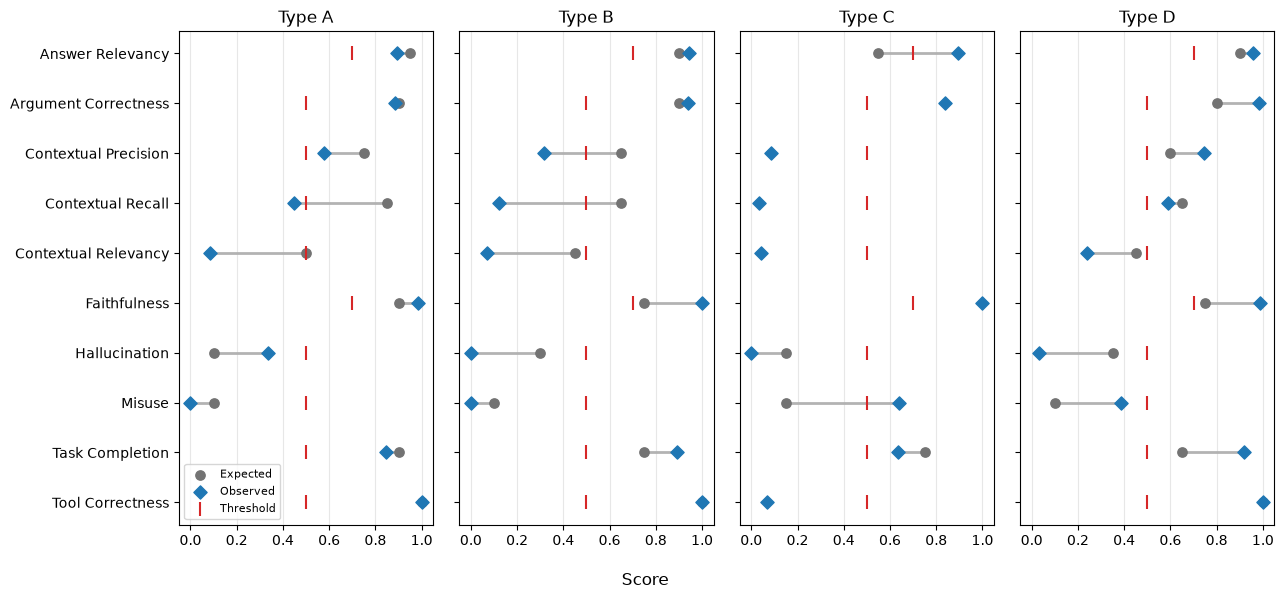

In [88]:
import matplotlib.pyplot as plt

obs = by_type.pivot(index="metric", columns="type", values="mean_score")

fig, axes = plt.subplots(1, 4, figsize=(13, 6), sharey=True)

for ax, t in zip(axes, ["A", "B", "C", "D"]):
    metrics = obs.index[::-1]
    y = range(len(metrics))
    e = expected.loc[metrics, t]
    o = obs.loc[metrics, t]

    ax.hlines(y, e, o, color="0.7", lw=2, zorder=1)
    ax.scatter(e, y, s=45, color="0.45", marker="o", zorder=2, label="Expected")
    ax.scatter(o, y, s=45, color="tab:blue", marker="D", zorder=3, label="Observed")
    ax.scatter([THR[m] for m in metrics], y, s=90, color="tab:red",
               marker="|", zorder=4, label="Threshold")

    ax.set_xlim(-0.05, 1.05)
    ax.set_title(f"Type {t}")
    ax.grid(axis="x", alpha=0.3)

axes[0].set_yticks(range(len(obs.index)))
axes[0].set_yticklabels(obs.index[::-1])
axes[0].legend(loc="lower left", fontsize=8)
fig.supxlabel("Score")
fig.tight_layout()
fig.savefig("fig_expected_vs_observed.pdf")

In [89]:
INVERTED = {"Hallucination", "Misuse"}

df["threshold"] = df["metric"].map(THR)
df["verdict"] = df.apply(
    lambda r: r.score <= r.threshold if r.metric in INVERTED
              else r.score >= r.threshold, axis=1)

In [90]:
flips = (
    df.groupby(["id", "metric"], as_index=False)
      .agg(n_pass=("verdict", "sum"), n=("verdict", "size"))
)
flips["unstable"] = ~flips.n_pass.isin([0, flips.n.iloc[0]])
flips["minority"] = flips[["n_pass"]].assign(fail=flips.n - flips.n_pass).min(axis=1)

flips

,id,metric,n_pass,n,unstable,minority
0,TC-A1,Answer Relevancy,9,10,True,1
1,TC-A1,Argument Correctness,10,10,False,0
2,TC-A1,Contextual Precision,10,10,False,0
3,TC-A1,Contextual Recall,8,10,True,2
4,TC-A1,Contextual Relevancy,0,10,False,0
...,...,...,...,...,...,...
115,TC-D3,Faithfulness,10,10,False,0
116,TC-D3,Hallucination,10,10,False,0
117,TC-D3,Misuse,6,10,True,4
118,TC-D3,Task Completion,10,10,False,0


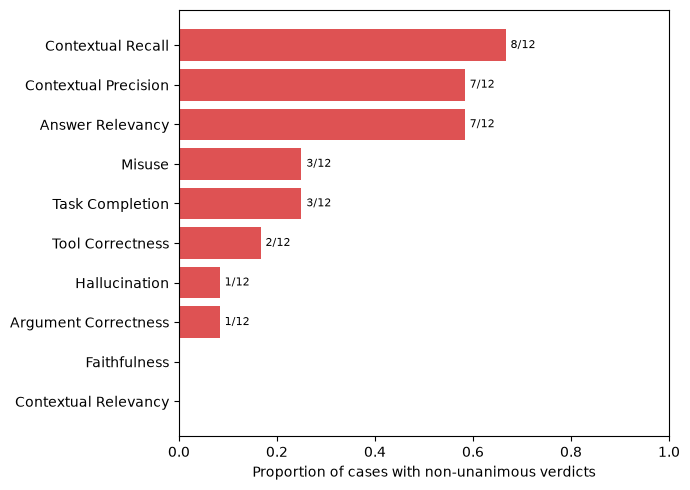

In [91]:
flip_summary = (
    flips.groupby("metric")
         .agg(flip_rate=("unstable", "mean"),
              modal_disagreement=("minority", lambda s: s.sum() / (len(s) * 5)),
              n_unstable=("unstable", "sum"))
         .sort_values("flip_rate", ascending=False)
)

fig, ax = plt.subplots(figsize=(7, 5))
s = flip_summary.sort_values("flip_rate")
ax.barh(s.index, s.flip_rate, color="tab:red", alpha=0.8)
ax.set_xlabel("Proportion of cases with non-unanimous verdicts")
ax.set_xlim(0, 1)
for i, (v, n) in enumerate(zip(s.flip_rate, s.n_unstable)):
    if v > 0:
        ax.text(v + 0.01, i, f"{n}/12", va="center", fontsize=8)
fig.tight_layout()

In [92]:
sd_wide   = by_type.pivot(index="metric", columns="type", values="mean_sd")
flip_wide = (flips.assign(type=flips.id.str.extract(r"TC-([A-D])")[0])
                  .groupby(["metric", "type"]).unstable.sum()
                  .unstack().reindex(sd_wide.index))

labels = sd_wide.round(3).astype(str) + flip_wide.fillna(0).map(lambda n: "*" * int(n))

sns.heatmap(sd_wide, annot=labels, fmt="", cmap="Reds", vmin=0, vmax=0.15,
            linewidths=0.5, cbar_kws={"label": "Within-case SD"})

KeyError: 'mean_sd'

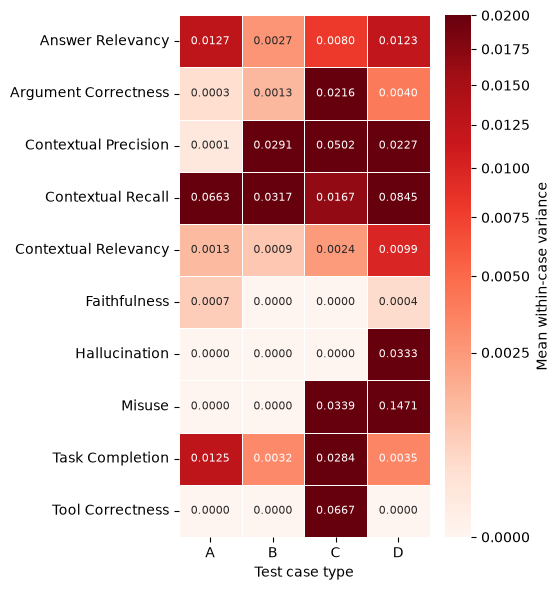

In [93]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import PowerNorm

# mean within-case variance per metric per type
var_wide = (
    disp.assign(var=disp["sd"] ** 2)
        .groupby(["metric", "type"])["var"].mean()
        .unstack()
)

fig, ax = plt.subplots(figsize=(5.5, 6))
sns.heatmap(
    var_wide,
    annot=True, fmt=".4f", annot_kws={"size": 8},
    cmap="Reds",
    norm=PowerNorm(gamma=0.5, vmin=0, vmax=0.02),
    linewidths=0.5, linecolor="white",
    cbar_kws={"label": "Mean within-case variance"},
    ax=ax,
)
ax.set_xlabel("Test case type")
ax.set_ylabel("")
ax.tick_params(axis="y", rotation=0)
fig.tight_layout()
fig.savefig("fig_variance_by_type.pdf")

In [36]:
import pingouin as pg

def icc_for(metric):
    m = df[df.metric == metric]
    per_case = m.groupby("id").score
    
    # guard against degenerate cases
    if per_case.mean().var(ddof=1) < 1e-9:
        return None, None, "degenerate"
    
    t = pg.intraclass_corr(data=m, targets="id", raters="pass", ratings="score")
    r = t[t.Type == "ICC(1,1)"].iloc[0]
    return r.ICC, r.CI95, "estimable"

icc = {m: icc_for(m) for m in df.metric.unique()}
icc["Tool Correctness"] = (None, None, "structurally invariant")

c:\Users\abdul\langgraph-agent\.venv\Lib\site-packages\pingouin\parametric.py:1008: RuntimeWarning: divide by zero encountered in scalar divide
  fval = msbetween / mserror
c:\Users\abdul\langgraph-agent\.venv\Lib\site-packages\pingouin\reliability.py:361: RuntimeWarning: divide by zero encountered in scalar divide
  f1k = msb / msw
c:\Users\abdul\langgraph-agent\.venv\Lib\site-packages\pingouin\reliability.py:366: RuntimeWarning: divide by zero encountered in scalar divide
  f2k = f3k = msb / mse
c:\Users\abdul\langgraph-agent\.venv\Lib\site-packages\pingouin\reliability.py:387: RuntimeWarning: invalid value encountered in scalar divide
  l1 = (f1l - 1) / (f1l + (k - 1))
c:\Users\abdul\langgraph-agent\.venv\Lib\site-packages\pingouin\reliability.py:388: RuntimeWarning: invalid value encountered in scalar divide
  u1 = (f1u - 1) / (f1u + (k - 1))
c:\Users\abdul\langgraph-agent\.venv\Lib\site-packages\pingouin\reliability.py:391: RuntimeWarning: invalid value encountered in scalar divid

In [94]:
icc_df = pd.DataFrame(
    [{"metric": m, "icc": v[0],
      "lo": v[1][0] if v[1] is not None else None,
      "hi": v[1][1] if v[1] is not None else None,
      "status": v[2]}
     for m, v in icc.items()]
).sort_values("icc", na_position="first")

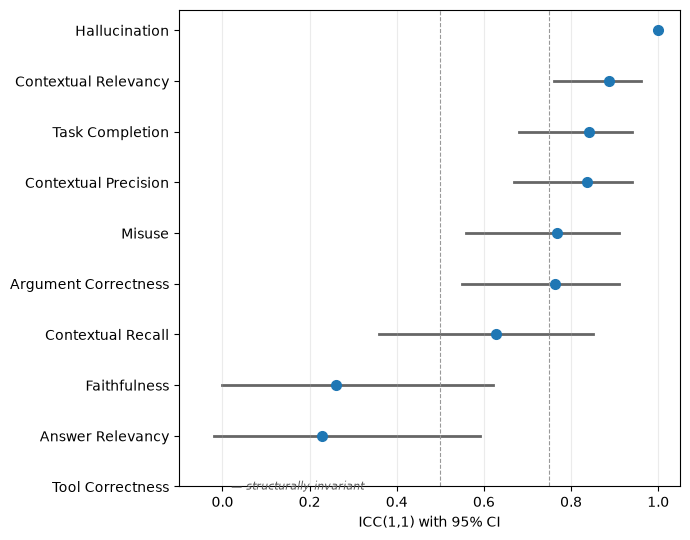

In [95]:
import matplotlib.pyplot as plt

est = icc_df[icc_df.status == "estimable"]
other = icc_df[icc_df.status != "estimable"]

fig, ax = plt.subplots(figsize=(7, 5.5))
y = range(len(icc_df))

# estimable metrics: point + CI
for i, (_, r) in enumerate(icc_df.iterrows()):
    if r.status == "estimable":
        ax.plot([r.lo, r.hi], [i, i], color="0.4", lw=2, zorder=1)
        ax.plot(r.icc, i, "o", color="tab:blue", ms=7, zorder=2)
    else:
        ax.text(0.02, i, f"— {r.status}", va="center",
                fontsize=8, style="italic", color="0.35")

for x in (0.5, 0.75):
    ax.axvline(x, ls="--", lw=0.8, color="0.6")

ax.set_yticks(list(y))
ax.set_yticklabels(icc_df.metric)
ax.set_xlim(-0.1, 1.05)
ax.set_xlabel("ICC(1,1) with 95% CI")
ax.grid(axis="x", alpha=0.25)
fig.tight_layout()
fig.savefig("fig_icc_forest.pdf")

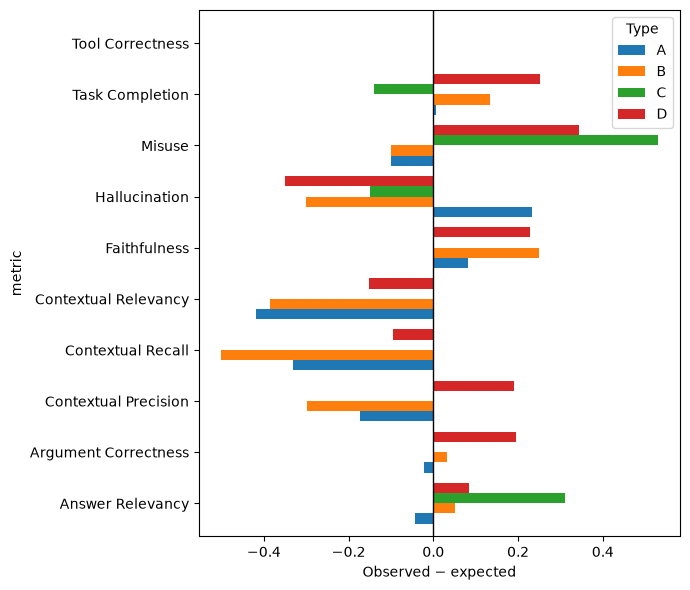

In [21]:
resid = (by_type.pivot(index="metric", columns="type", values="mean_score")
         - expected)

ax = resid.plot(kind="barh", figsize=(7, 6), width=0.8)
ax.axvline(0, color="black", lw=1)
ax.set_xlabel("Observed − expected")
ax.legend(title="Type")
plt.tight_layout()

In [19]:
by_type = (
    disp.groupby(["metric", "type"], as_index=False)
        .agg(mean_score=("mean", "mean"),
             mean_sd=("sd", lambda s: (s.pow(2).mean()) ** 0.5),
             max_sd=("sd", "max"))
)

by_type.pivot(index="metric", columns="type", values=["mean_sd", "max_sd"]).round(3)

mean_sd                      max_sd                     
type                       A      B      C      D      A      B      C      D
metric                                                                       
Answer Relevancy       0.091  0.053  0.051  0.048  0.111  0.072  0.066  0.084
Argument Correctness   0.033  0.000  0.056  0.017  0.058  0.000  0.096  0.029
Contextual Precision   0.022  0.192  0.211  0.027  0.038  0.289  0.366  0.038
Contextual Recall      0.200  0.222  0.000  0.250  0.289  0.333  0.000  0.289
Contextual Relevancy   0.037  0.029  0.025  0.047  0.056  0.039  0.043  0.062
Faithfulness           0.031  0.000  0.000  0.030  0.048  0.000  0.000  0.050
Hallucination          0.000  0.000  0.000  0.000  0.000  0.000  0.000  0.000
Misuse                 0.000  0.000  0.042  0.471  0.000  0.000  0.072  0.577
Task Completion        0.017  0.075  0.047  0.039  0.029  0.126  0.058  0.050
Tool Correctness       0.000  0.000  0.000  0.000  0.000  0.000  0.000  0.000

In [47]:
(disp.groupby("metric")
     .agg(mean_sd=("sd", lambda s: (s.pow(2).mean()) ** 0.5),
          max_sd=("sd", "max"),
          worst_case=("sd", "idxmax"))
     .sort_values("mean_sd", ascending=False)
     .round(3))

,mean_sd,max_sd,worst_case
metric,,,
Misuse,0.237,0.577,107
Contextual Recall,0.195,0.333,33
Contextual Precision,0.144,0.366,82
Answer Relevancy,0.063,0.111,10
Task Completion,0.049,0.126,38
Contextual Relevancy,0.036,0.062,94
Argument Correctness,0.033,0.096,81
Faithfulness,0.022,0.050,115
Hallucination,0.000,0.000,6


In [48]:
worst = disp.sort_values("sd", ascending=False).head(5)
worst[["id", "metric", "mean", "sd", "range"]]

,id,metric,mean,sd,range
117,TC-D3,Misuse,0.666667,0.577350,1.000000
107,TC-D2,Misuse,0.666667,0.577350,1.000000
82,TC-C3,Contextual Precision,0.211111,0.365655,0.633333
33,TC-B1,Contextual Recall,0.333333,0.333333,0.666667
113,TC-D3,Contextual Recall,0.666667,0.288675,0.500000


In [ ]:
by_metric = (
    disp.groupby("metric", as_index=False) # group by metric for all TESTCASES (over disp values) to get the mean_score
        .agg(mean_score=("mean", "mean"), # mean_sd, max_sd, mean_range and max_range for each metric.
             mean_sd=("sd", "mean"),
             max_sd=("sd", "max"),
             mean_range=("range", "mean"),
             max_range=("range", "max"))
)
display(by_metric.sort_values("mean_sd", ascending=False).round(4))

,metric,mean_score,mean_sd,max_sd,mean_range,max_range
3,Contextual Recall,0.3021,0.1281,0.3536,0.2153,0.6667
2,Contextual Precision,0.4469,0.0823,0.3657,0.1441,0.6333
7,Misuse,0.2951,0.0649,0.7071,0.0938,1.0000
0,Answer Relevancy,0.9236,0.0549,0.1114,0.0993,0.1935
8,Task Completion,0.8271,0.0347,0.1258,0.0600,0.2500
4,Contextual Relevancy,0.1167,0.0309,0.0824,0.0525,0.1165
1,Argument Correctness,0.9183,0.0158,0.0962,0.0264,0.1667
5,Faithfulness,0.9929,0.0062,0.0481,0.0108,0.0833
6,Hallucination,0.0833,0.0000,0.0000,0.0000,0.0000
9,Tool Correctness,0.7500,0.0000,0.0000,0.0000,0.0000


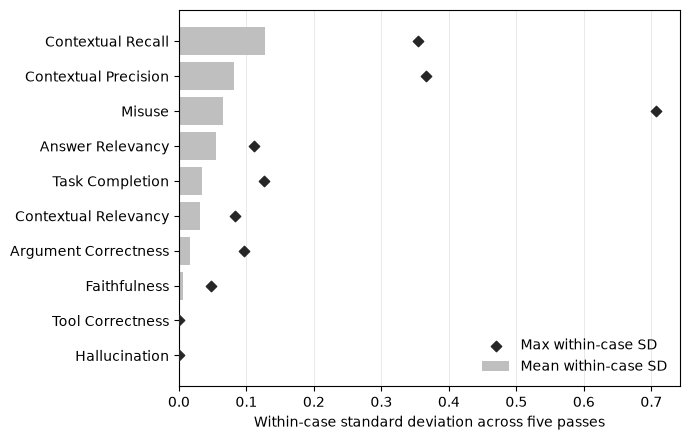

In [ ]:
#One horizontal bar per metric, sorted by mean_sd, with max_sd overlaid as a marker.
# That puts both numbers in one figure and makes the mean/max gap visible — a metric with a low bar 
# and a far-right marker is the "stable on eleven cases, fell apart on one" case you care about for RQ3.

import matplotlib.pyplot as plt

d = by_metric.sort_values("mean_sd")          # ascending → worst at top

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.barh(d["metric"], d["mean_sd"], color="0.75", label="Mean within-case SD")
ax.scatter(d["max_sd"], d["metric"], marker="D", s=28,
           color="0.15", zorder=3, label="Max within-case SD")

ax.set_xlabel("Within-case standard deviation across five passes")
ax.set_xlim(0, None)
ax.grid(axis="x", linewidth=0.4, alpha=0.5)
ax.set_axisbelow(True)
ax.legend(frameon=False, loc="lower right")
fig.tight_layout()
fig.savefig("fig_rq1_dispersion.pdf")

In [ ]:

import matplotlib.pyplot as plt

d = by_metric.sort_values("mean_sd")          # ascending → worst at top

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.barh(d["metric"], d["mean_sd"], color="0.75", label="Mean within-case SD")
ax.scatter(d["max_sd"], d["metric"], marker="D", s=28,
           color="0.15", zorder=3, label="Max within-case SD")

ax.set_xlabel("Within-case standard deviation across five passes")
ax.set_xlim(0, None)
ax.grid(axis="x", linewidth=0.4, alpha=0.5)
ax.set_axisbelow(True)
ax.legend(frameon=False, loc="lower right")
fig.tight_layout()
fig.savefig("fig_rq1_dispersion.pdf")

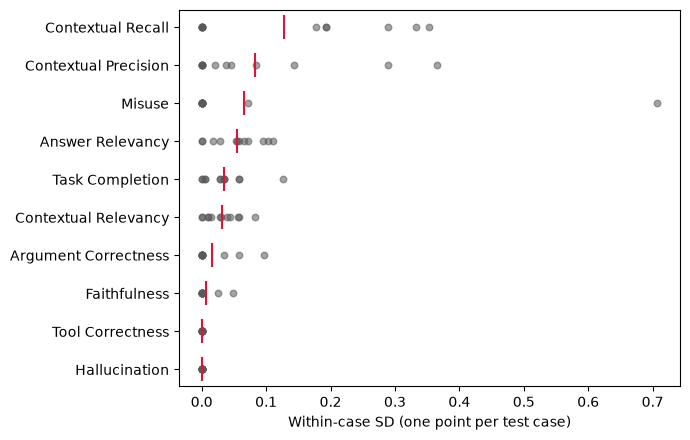

In [ ]:
#The bar chart shows two summary numbers per metric. A strip plot shows all twelve within-case SDs, 
# so the shape of the distribution is visible — whether a high mean_sd comes from uniform wobble or 
# from one outlier dragging it up.

order = d["metric"].tolist()
pos = {m: i for i, m in enumerate(order)}

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.scatter(disp["sd"], disp["metric"].map(pos), alpha=0.55, s=22, color="0.35")
ax.scatter(d["mean_sd"], range(len(order)), marker="|", s=300, color="crimson")
ax.set_yticks(range(len(order)), order)
ax.set_xlabel("Within-case SD (one point per test case)")
fig.tight_layout()

# flip_rate — how often the pass/fail verdict changed on identical input.



In [ ]:
flips = (
    df.groupby(["id", "metric"], as_index=False)
      .agg(n=("success", "size"), n_true=("success", "sum"))
)
flips["flipped"] = (flips["n_true"] != 0) & (flips["n_true"] != flips["n"])

flip_rate = (
    flips.groupby("metric", as_index=False)
         .agg(n_cases=("id", "nunique"), n_flipped=("flipped", "sum"))
)   
flip_rate["flip_rate"] = flip_rate["n_flipped"] / flip_rate["n_cases"]

display(flip_rate.sort_values("flip_rate", ascending=False).round(3))

# the specific cases that flipped
display(flips[flips["flipped"]][["metric", "id", "n_true", "n"]]
        .sort_values(["metric", "id"]))

,metric,n_cases,n_flipped,flip_rate
0,Answer Relevancy,12,0,0.0
1,Argument Correctness,12,0,0.0
2,Contextual Precision,12,0,0.0
3,Contextual Recall,12,0,0.0
4,Contextual Relevancy,12,0,0.0
5,Faithfulness,12,0,0.0
6,Hallucination,12,0,0.0
7,Misuse,12,0,0.0
8,Task Completion,12,0,0.0
9,Tool Correctness,12,0,0.0


,metric,id,n_true,n


In [38]:
mean_id = df.groupby("metric")["score"].max()
display(mean_id)

metric
Answer Relevancy        1.000000
Argument Correctness    1.000000
Contextual Precision    0.876667
Contextual Recall       1.000000
Contextual Relevancy    0.380952
Faithfulness            1.000000
Hallucination           1.000000
Misuse                  1.000000
Task Completion         0.960000
Tool Correctness        1.000000
Name: score, dtype: float64

Intraclass Correlation Coefficient (ICC) compares two things: how much the scores differ **between test cases**, and how
much they wobble **within the same test case across the five passes**.

In [16]:
import pingouin as pg

DETERMINISTIC = {"Tool Correctness"}   # judge never invoked

def icc_one(metric):
    if metric in DETERMINISTIC:
        return {"metric": metric, "icc": None, "ci": None,
                "status": "deterministic (judge not invoked)"}

    sub = df[df["metric"] == metric]
    if sub["score"].nunique() == 1:
        return {"metric": metric, "icc": None, "ci": None, "status": "constant score"}
    if sub.groupby("id")["score"].mean().std() == 0:
        return {"metric": metric, "icc": None, "ci": None, "status": "no between-case variance"}
    if sub.groupby("id")["score"].std().fillna(0).max() == 0:
        return {"metric": metric, "icc": 1.0, "ci": None, "status": "perfect agreement"}

    r = pg.intraclass_corr(sub, targets="id", raters="pass", ratings="score")
    row = r[r["Type"].astype(str).isin(["ICC(1,1)", "ICC1"])].iloc[0]
    ci = row["CI95"] if "CI95" in r.columns else row["CI95%"]
    return {"metric": metric, "icc": round(float(row["ICC"]), 3),
            "ci": f"[{ci[0]:.2f}, {ci[1]:.2f}]", "status": "estimated"}

icc_df = pd.DataFrame([icc_one(m) for m in df["metric"].unique()])
display(icc_df.sort_values("icc", ascending=False, na_position="last"))

,metric,icc,ci,status
1,Argument Correctness,1.0,None,perfect agreement
2,Task Completion,1.0,None,perfect agreement
3,Faithfulness,1.0,None,perfect agreement
4,Answer Relevancy,1.0,None,perfect agreement
5,Hallucination,1.0,None,perfect agreement
6,Contextual Recall,1.0,None,perfect agreement
7,Contextual Precision,1.0,None,perfect agreement
8,Contextual Relevancy,1.0,None,perfect agreement
9,Misuse,1.0,None,perfect agreement
0,Tool Correctness,NaN,None,deterministic (judge not invoked)


## 7. ICC(1,1)

Dispersion alone does not tell you whether a metric is *useful*. A metric could be perfectly steady
and still assign every case the same score — steady but uninformative. ICC(1,1) compares
between-case variance against within-case (across-pass) variance. High ICC means the metric
separates cases by more than it jitters.

ICC(1,1) rather than ICC(2,1) because the five passes are exchangeable replicates, not persistent
raters with their own identities.

Three degenerate cases are labelled rather than given a number:

- **deterministic (judge not invoked)** — configured in `DETERMINISTIC_METRICS`. Structural, not empirical.
- **no between-case variance** — every case scored identically; ICC is undefined and meaningless.
- **perfect agreement across passes** — zero within-case variance; ICC = 1 by construction.

## 8. Master summary table

One row per metric — this is the table that goes into Chapter 5.

In [19]:
# summary = (
#     disp.merge(flip[["metric", "n_cases", "n_flipped", "flip_rate"]], on="metric")
#         .merge(icc_df, on="metric")
# )
# if "pval" not in summary.columns:
#     summary["pval"] = np.nan

# summary = summary[[
#     "metric", "direction", "mean_score", "mean_sd", "max_sd", "mean_range",
#     "n_flipped", "n_cases", "flip_rate", "icc", "ci_lo", "ci_hi", "pval", "status",
# ]].sort_values(["flip_rate", "mean_sd"], ascending=False).reset_index(drop=True)

# summary.to_csv(OUT_DIR / "rq1_metric_summary.csv", index=False)
# grp.to_csv(OUT_DIR / "rq1_case_metric_groups.csv", index=False)
# flipped_cases.to_csv(OUT_DIR / "rq1_flipped_cases.csv", index=False)

# summary.round(4)

## 10. Figures

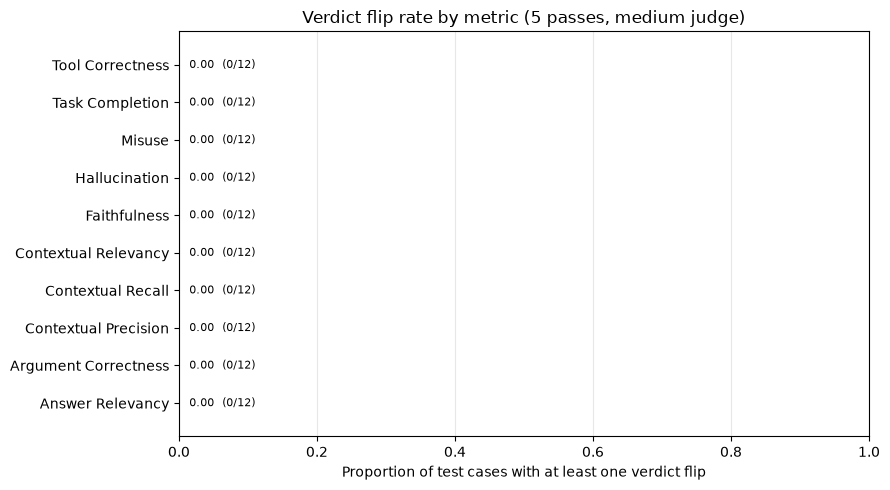

In [22]:
import matplotlib.pyplot as plt

p1 = flip_rate.sort_values("flip_rate")
fig, ax = plt.subplots(figsize=(9, 5))
colors = ["#c0392b" if v > 0 else "#95a5a6" for v in p1["flip_rate"]]
ax.barh(p1["metric"], p1["flip_rate"], color=colors)
ax.set_xlabel("Proportion of test cases with at least one verdict flip")
ax.set_xlim(0, 1)
ax.grid(axis="x", alpha=0.3); ax.set_axisbelow(True)
for y, (v, n, tot) in enumerate(zip(p1["flip_rate"], p1["n_flipped"], p1["n_cases"])):
    ax.text(v + 0.015, y, f"{v:.2f}  ({int(n)}/{int(tot)})", va="center", fontsize=8)
ax.set_title("Verdict flip rate by metric (5 passes, medium judge)")
fig.tight_layout()
fig.savefig("fig_flip_rate.png", dpi=200, bbox_inches="tight")
plt.show()

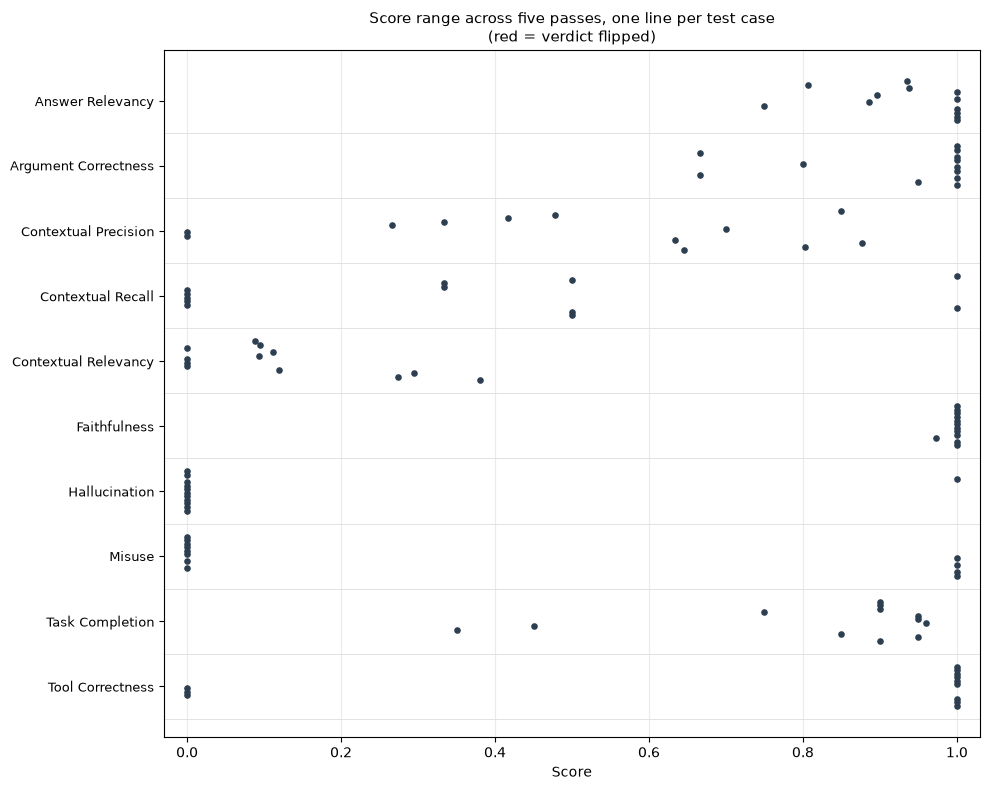

In [25]:
import numpy as np

order = by_metric.sort_values("mean_sd", ascending=False)["metric"].tolist()
flipped_ids = {(r.metric, r.id) for r in flips[flips["flipped"]].itertuples()}

fig, ax = plt.subplots(figsize=(10, 8))
for i, m in enumerate(order):
    sub = disp[disp["metric"] == m]
    offs = np.linspace(-0.30, 0.30, len(sub))
    for off, r in zip(offs, sub.itertuples()):
        c = "#c0392b" if (m, r.id) in flipped_ids else "#2c3e50"
        ax.plot([r.min, r.max], [i + off, i + off], color=c, alpha=0.55, lw=1.2, zorder=2)
        ax.scatter([r.mean], [i + off], s=14, color=c, zorder=3)
    ax.axhline(i + 0.5, color="#dddddd", lw=0.6, zorder=1)

ax.set_yticks(range(len(order))); ax.set_yticklabels(order, fontsize=9)
ax.set_xlabel("Score"); ax.set_xlim(-0.03, 1.03)
ax.grid(axis="x", alpha=0.25); ax.set_axisbelow(True); ax.invert_yaxis()
ax.set_title("Score range across five passes, one line per test case\n(red = verdict flipped)", fontsize=11)
fig.tight_layout()
fig.savefig("fig_dispersion.png", dpi=200, bbox_inches="tight")
plt.show()

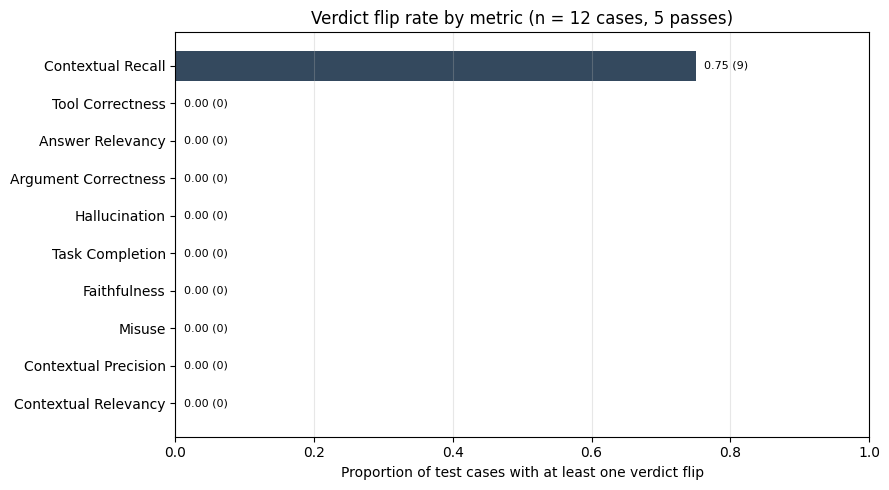

In [14]:
plot_df = summary.sort_values("flip_rate")
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(plot_df["metric"], plot_df["flip_rate"], color="#34495e")
ax.set_xlabel("Proportion of test cases with at least one verdict flip")
ax.set_xlim(0, 1)
ax.grid(axis="x", alpha=0.3)
for y, (v, n) in enumerate(zip(plot_df["flip_rate"], plot_df["n_flipped"])):
    ax.text(v + 0.012, y, f"{v:.2f} ({int(n)})", va="center", fontsize=8)
ax.set_title("Verdict flip rate by metric (n = 12 cases, 5 passes)")
fig.tight_layout()
fig.savefig(OUT_DIR / "rq1_flip_rate.png", dpi=200, bbox_inches="tight")
plt.show()

## 11. LaTeX table

Paste straight into `sections/5_results_analysis.tex`. Degenerate metrics print their status label
in place of a number, so a reader cannot mistake structural invariance for empirical stability.

In [15]:
def fmt_icc(row):
    if row["status"] == "estimated":
        if pd.notna(row["ci_lo"]):
            return f"{row['icc']:.2f} [{row['ci_lo']:.2f}, {row['ci_hi']:.2f}]"
        return f"{row['icc']:.2f}"
    return r"\textit{" + row["status"].split(",")[0] + "}"


lines = [
    r"\begin{table}[htbp]",
    r"\centering",
    r"\renewcommand{\arraystretch}{1.2}",
    r"\caption{Repeat-run stability of ten component-level metrics. Medium judge, five independent "
    r"scoring passes over twelve frozen test cases. Flip rate is the proportion of test cases whose "
    r"pass/fail verdict changed at least once.}",
    r"\label{tab:rq1_stability}",
    r"\begin{tabular}{lcccc}",
    r"\hline",
    r"Metric & Mean SD & Mean range & Flip rate & ICC(1,1) [95\% CI] \\",
    r"\hline",
]
for _, r in summary.sort_values("metric").iterrows():
    name = r["metric"]
    lines.append(
        f"{name} & {r['mean_sd']:.3f} & {r['mean_range']:.3f} & "
        f"{r['flip_rate']:.2f} ({int(r['n_flipped'])}/{int(r['n_cases'])}) & {fmt_icc(r)} \\\\"
    )
lines += [r"\hline", r"\end{tabular}", r"\end{table}"]

latex = "\n".join(lines)
(OUT_DIR / "rq1_stability_table.tex").write_text(latex, encoding="utf-8")
print(latex)

\begin{table}[htbp]
\centering
\renewcommand{\arraystretch}{1.2}
\caption{Repeat-run stability of ten component-level metrics. Medium judge, five independent scoring passes over twelve frozen test cases. Flip rate is the proportion of test cases whose pass/fail verdict changed at least once.}
\label{tab:rq1_stability}
\begin{tabular}{lcccc}
\hline
Metric & Mean SD & Mean range & Flip rate & ICC(1,1) [95\% CI] \\
\hline
Answer Relevancy & 0.014 & 0.032 & 0.00 (0/12) & 0.87 [0.74, 0.96] \\
Argument Correctness & 0.025 & 0.060 & 0.00 (0/12) & 0.61 [0.36, 0.84] \\
Contextual Precision & 0.064 & 0.151 & 0.00 (0/12) & 0.43 [0.18, 0.73] \\
Contextual Recall & 0.081 & 0.199 & 0.75 (9/12) & 0.27 [0.04, 0.60] \\
Contextual Relevancy & 0.082 & 0.200 & 0.00 (0/12) & 0.33 [0.10, 0.66] \\
Faithfulness & 0.048 & 0.117 & 0.00 (0/12) & 0.46 [0.21, 0.75] \\
Hallucination & 0.039 & 0.099 & 0.00 (0/12) & 0.76 [0.56, 0.91] \\
Misuse & 0.053 & 0.124 & 0.00 (0/12) & 0.40 [0.16, 0.71] \\
Task Completion & 0.0

## 12. Written findings

A plain-language readout to check your interpretation against before drafting §5.x. It is a
scaffold for your own prose, not text to paste.

In [16]:
est = summary[summary["status"] == "estimated"]

print("RQ1 READOUT")
print("=" * 60)
print(f"Groups analysed        : {len(grp)} (case x metric), {N_PASSES_EXPECTED} passes each")
print(f"Groups that flipped    : {int(grp['flipped'].sum())} ({grp['flipped'].mean():.1%})")
print(f"Metrics with any flip  : {int((summary['n_flipped'] > 0).sum())} of {len(summary)}")
print()

no_flip = summary[summary["n_flipped"] == 0]["metric"].tolist()
some_flip = summary[summary["n_flipped"] > 0].sort_values("flip_rate", ascending=False)

print("Verdict-stable across all five passes:")
for m in no_flip:
    tag = " (structurally deterministic)" if m in DETERMINISTIC_METRICS else ""
    print(f"  - {m}{tag}")

print("\nVerdict-unstable (ranked):")
for _, r in some_flip.iterrows():
    print(f"  - {r['metric']}: {r['flip_rate']:.0%} of cases, mean SD {r['mean_sd']:.3f}")

if len(est):
    print("\nICC(1,1), estimated metrics only:")
    for _, r in est.sort_values("icc", ascending=False).iterrows():
        ci = f" [{r['ci_lo']:.2f}, {r['ci_hi']:.2f}]" if pd.notna(r["ci_lo"]) else ""
        print(f"  - {r['metric']}: {r['icc']:.2f}{ci}")

print("\nReport alongside these numbers:")
print(f"  - Five passes resolve flip rate only to multiples of 1/{N_CASES_EXPECTED} across cases;")
print("    per-case verdict patterns resolve only to multiples of 20 percent.")
print(f"  - ICC confidence intervals are wide at n = {N_CASES_EXPECTED} cases.")
print("  - Tool Correctness invariance is structural (judge never invoked), not empirical.")
print("  - Stability is necessary but not sufficient: a metric can be perfectly repeatable")
print("    and still be measuring the wrong thing.")

RQ1 READOUT
Groups analysed        : 120 (case x metric), 5 passes each
Groups that flipped    : 9 (7.5%)
Metrics with any flip  : 1 of 10

Verdict-stable across all five passes:
  - Contextual Relevancy
  - Contextual Precision
  - Misuse
  - Faithfulness
  - Hallucination
  - Task Completion
  - Argument Correctness
  - Answer Relevancy
  - Tool Correctness (structurally deterministic)

Verdict-unstable (ranked):
  - Contextual Recall: 75% of cases, mean SD 0.081

ICC(1,1), estimated metrics only:
  - Answer Relevancy: 0.87 [0.74, 0.96]
  - Hallucination: 0.76 [0.56, 0.91]
  - Task Completion: 0.70 [0.47, 0.88]
  - Argument Correctness: 0.61 [0.36, 0.84]
  - Faithfulness: 0.46 [0.21, 0.75]
  - Contextual Precision: 0.43 [0.18, 0.73]
  - Misuse: 0.40 [0.16, 0.71]
  - Contextual Relevancy: 0.33 [0.10, 0.66]
  - Contextual Recall: 0.27 [0.04, 0.60]

Report alongside these numbers:
  - Five passes resolve flip rate only to multiples of 1/12 across cases;
    per-case verdict patterns res